In [9]:
import pandas as pd
import numpy as np

data = pd.read_csv('/home/ezreals_/Code/NoteBook/MachineLearning/Week5/Dataset/dataset.csv')

In [10]:
data.head()
data.shape
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


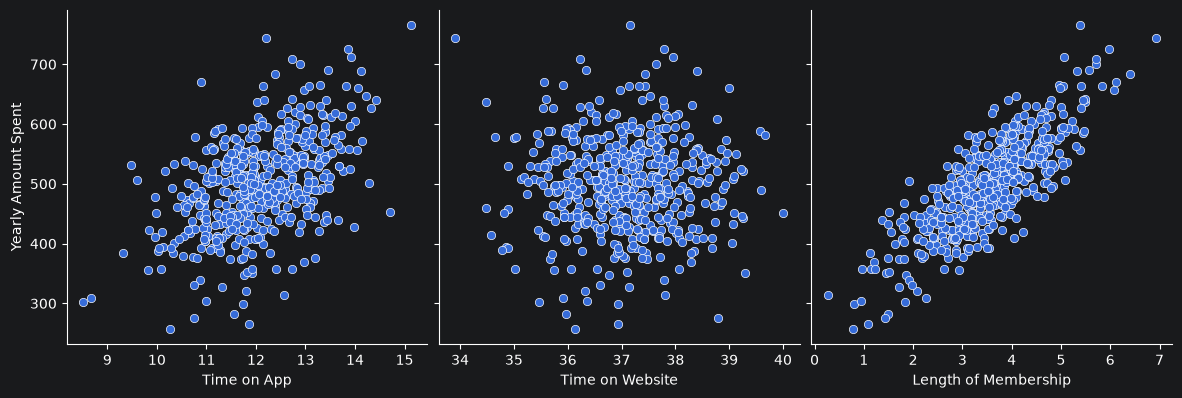

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(data, x_vars=['Time on App', 'Time on Website', 'Length of Membership'], y_vars='Yearly Amount Spent', height=4, aspect=1, kind='scatter')
plt.show()

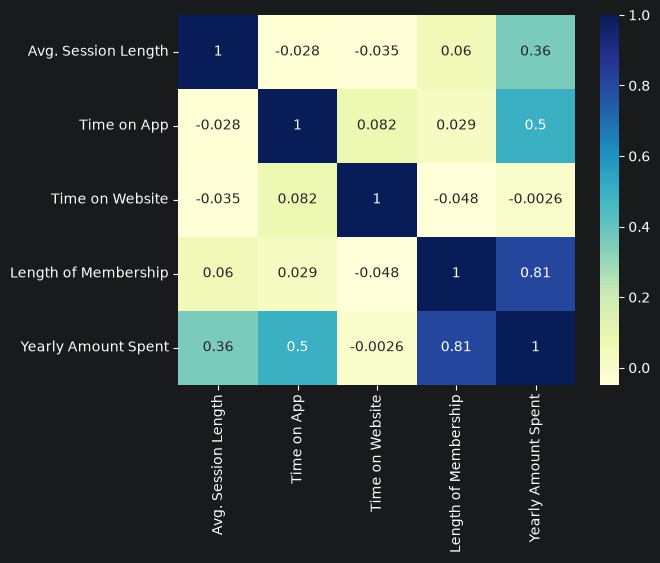

In [13]:
sns.heatmap(data.corr(numeric_only=True), cmap='YlGnBu', annot=True)
plt.show()

In [14]:
X = data['Length of Membership']
y = data['Yearly Amount Spent']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.2,random_state=100)

In [17]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train, X_train_sm).fit()

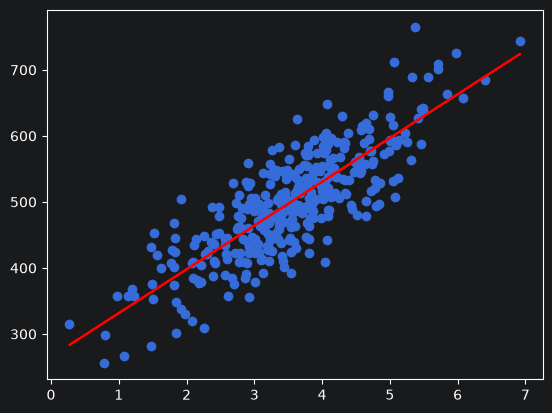

In [18]:
plt.scatter(X_train, y_train)
plt.plot(X_train, 265.2483 + 66.3015 * X_train, 'r')
plt.show()

/tmp/ipykernel_106743/2963028114.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res, bins=15)


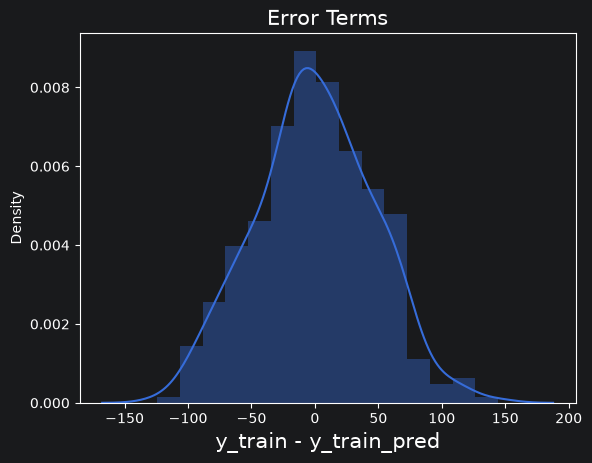

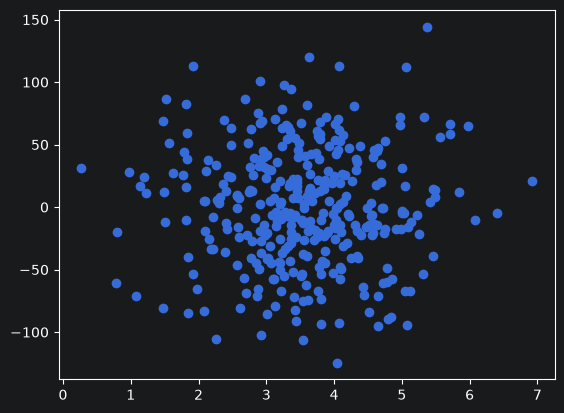

In [21]:
y_train_pred = lr.predict(X_train_sm)
res = (y_train - y_train_pred)

fig = plt.figure()
sns.distplot(res, bins=15)
plt.title('Error Terms', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize=15)
plt.show()

# Scatter plot residual
plt.scatter(X_train, res)
plt.show()

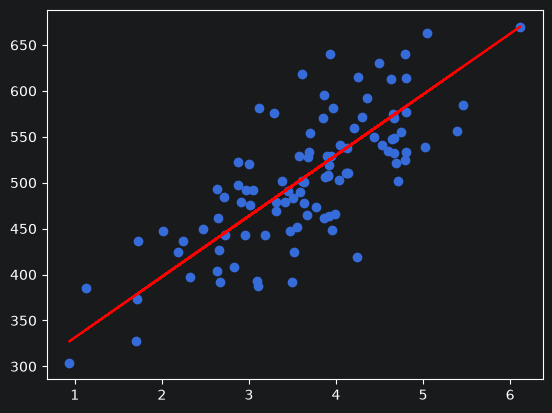

In [22]:
X_test_sm = sm.add_constant(X_test)
y_test_pred = lr.predict(X_test_sm)

from sklearn.metrics import r2_score
r_squared = r2_score(y_test, y_test_pred)

plt.scatter(X_test, y_test)
plt.plot(X_test, y_test_pred, 'r')
plt.show()